__Markus Mulvihill__

__Last updated May 2026__

# Necessary Packages and Modules

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tomllib
from matplotlib import rcParams

In [4]:
FIG_WIDTH = 7.5  # width of figure in inches

TINY_SIZE = 6
SMALL_SIZE = 8
MEDIUM_SIZE = 10
BIGGER_SIZE = 12

plt.rc("font", size=SMALL_SIZE)  # controls default text sizes
plt.rc("axes", titlesize=TINY_SIZE, titleweight="bold")  # fontsize of the axes title
plt.rc("axes", labelsize=SMALL_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=TINY_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=TINY_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=TINY_SIZE)  # legend fontsize
plt.rc("figure", titlesize=BIGGER_SIZE)  # fontsize of the figure title

rcParams["axes.spines.top"] = False
rcParams["axes.spines.right"] = False

# Introduction
The goal of this file is to demonstrate the limitations of the integral parameter estimation used to calculate insulin sensitivity $S_I$

In [5]:
try:
    SI_ests_02 = np.load("../scripts/variables/SI_ests_02.npy")
    SI_est_error_02 = np.load("../scripts/variables/SI_est_error_02.npy")
    meas_noise_std_02 = np.load("../scripts/variables/meas_noise_std_02.npy")
    print("Loaded variables")
except Exception:
    print("Run 02_Integral_Estimation.py")

Loaded variables


In [6]:
with open("../config.toml", "rb") as f:
    cfg = tomllib.load(f)
curr_module = "02"
low_perc = cfg[curr_module]["low_perc"]
high_perc = cfg[curr_module]["high_perc"]
CI = cfg[curr_module]["CI"]

# Plot Results
+ The distribution of $\,SI$ estimates will be plotted over time
+ The MARD (90% CI) error will be plotted along for each measurement noise std $\sigma$

In [7]:
mean_err = np.mean(SI_est_error_02, axis=1)
mean_SI = np.mean(SI_ests_02, axis=1)
ci_low = np.percentile(SI_est_error_02, low_perc, axis=1)
ci_high = np.percentile(SI_est_error_02, high_perc, axis=1)
time = 60 * np.arange(mean_err.shape[1])

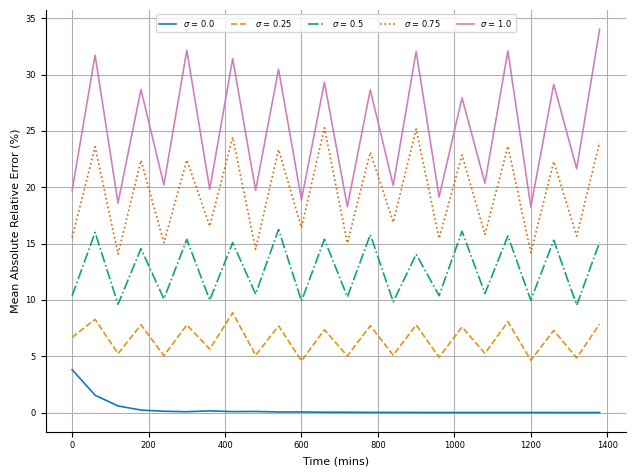

In [ ]:
num_plots = mean_err.shape[0]
palette = sns.color_palette("colorblind", num_plots)

fig, ax = plt.subplots()
for i in range(num_plots):
    ax.plot(
        time,
        mean_err[i, :],
        color=palette[i],
        linewidth=1.2,
        alpha=0.95,
        linestyle=["-", "--", "-.", ":"][i % 4],
        label=f"$\\sigma$ = {meas_noise_std_02[i]}",
    )
    # ax.fill_between(time, ci_low[i, :], ci_high[i, :], color=palette[i], alpha=0.18, label=f"{CI}% CI")

ax.legend(loc="upper center", ncols=5)
ax.set_xlabel("Time (mins)")
ax.set_ylabel("Mean Absolute Relative Error (%)")
ax.grid()
fig.tight_layout()
# fig.savefig("5_2.svg", format="svg")